# **“Rīgas dzīvokļu tirgus analīze klienta vajadzībām ar Machine Learning”**

## **Projekta mērķis**
Šī projekta mērķis ir analizēt Rīgas dzīvokļu tirgu un izmantot Machine Learning metodes, lai palīdzētu atrast piemērotākos dzīvokļus klientam pēc viņa vajadzībām, budžeta un dzīves prasībām.
Projektā tiks analizēti dzīvokļu sludinājumu dati un pielietotas vairākas Machine Learning pieejas:
- Regression — dzīvokļa cenas prognozēšanai;
- Classification — premium dzīvokļu noteikšanai;
- Clustering — tirgus segmentācija.

Projektā tiek izmantota riga.csv datu kopa ar informāciju par Rīgas dzīvokļu piedāvājumiem.

## **Klienta profils**
Analīze tiek veikta konkrētam klienta scenārijam:
- sieviete ar bērnu (pusaudzis), 
- 2 istabu dzīvoklis, 
- platība 45–50 m², 
- vidēji ienākumi,
- ne pirmais un ne pēdējais stāvs, 
- budžets 65 000–75 000 €, 
- vēlams: 119.sērija, 104.sērija, renovēta ēka vai jaunais projekts, 
- vēlamie rajoni: Dārzciems, Imanta, Teika, Jugla, Mežciems.

## **Biznesa problēma**
Nekustamā īpašuma tirgū klientiem bieži ir grūti saprast:
- vai dzīvokļa cena ir adekvāta, 
- kuri rajoni atbilst budžetam, 
- kādi dzīvokļi ir “labāki” konkrētai dzīves situācijai. 

Machine Learning pieeja palīdz: prognozēt dzīvokļu cenas, identificēt premium īpašumus, sadalīt tirgu segmentos, palīdzēt klientam pieņemt pamatotāku lēmumu.

In [1]:
# Bibliotēku imports un datu ielāde:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML modeļi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# Vizualizācijas
sns.set_style("whitegrid")

# Ielādē datus
df = pd.read_csv('data/riga.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

# Pirmās rindas
df.head()

Datu kopa: 4157 rindas, 13 kolonnas


,op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
0,For rent,Purvciems,Dzelzavas 93,1,27.0,3.0,5.0,LT proj.,Brick-Panel,All amenities,250.0,56.955484,24.202139
1,For rent,Ziepniekkalns,Ozolciema 32,2,50.0,7.0,9.0,602.,Panel,All amenities,300.0,56.899798,24.098350
2,For sale,centrs,Ieroču 6,2,33.0,1.0,2.0,P. kara,Wood,Partial amenities,13500.0,56.975092,24.139884
3,For sale,Ķengarags,Maskavas 305,2,50.0,5.0,5.0,LT proj.,Panel,All amenities,34000.0,56.859788,24.308342
4,For rent,Teika,Zemgala gatve 80,3,76.0,3.0,12.0,Jaun.,Masonry,All amenities,490.0,56.977745,24.166042


In [2]:
# Kolonnu nosaukumi
print(df.columns)

# Informācija par datiem
df.info()

# Trūkstošās vērtības
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Kolonnu saraksts
print(df.columns.tolist())

Index(['op_type', 'district', 'street', 'rooms', 'area', 'floor',
       'total_floors', 'house_seria', 'house_type', 'condition', 'price',
       'lat', 'lon'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   op_type       4157 non-null   object 
 1   district      4157 non-null   object 
 2   street        4157 non-null   object 
 3   rooms         4157 non-null   int64  
 4   area          4157 non-null   float64
 5   floor         4157 non-null   float64
 6   total_floors  4157 non-null   float64
 7   house_seria   4157 non-null   object 
 8   house_type    4157 non-null   object 
 9   condition     4157 non-null   object 
 10  price         4157 non-null   float64
 11  lat           4157 non-null   float64
 12  lon           4157 non-null   float64
dtypes: float64(6), int64(1), object(6)
memory usage: 422.3+ KB


In [3]:
# Parāda visus unikālos rajonus, kas ir failā
print("Visi failā esošie rajoni:")
print(df['district'].unique())

# Parāda visas unikālās māju sērijas
print("Māju sērijas failā:")
print(df['house_seria'].unique())

Visi failā esošie rajoni:
['Purvciems' 'Ziepniekkalns' 'centrs' 'Ķengarags' 'Teika' 'Imanta' 'Jugla'
 'Mangaļi' 'Mežciems' 'Maskavas priekšpilsēta' 'Zolitūde' 'Bolderāja'
 'Grīziņkalns' 'Dreiliņi' 'Pļavnieki' 'Dzegužkalns' 'Ķīpsala'
 'Krasta r-ns' 'Klīversala' 'Vecmīlgrāvis' 'Āgenskalns' 'Zasulauks'
 'Mežaparks' 'Čiekurkalns' 'Sarkandaugava' 'Daugavgrīva' 'Iļģuciems'
 'Berģi' 'Šķirotava' 'Dārzciems' 'Vecrīga' 'Bieriņi' 'Brekši'
 'Kundziņsala' 'Jaunciems' 'Torņakalns' 'Mangaļsala'
 'Šampēteris-Pleskodāle' 'Bukulti' 'Voleri' 'Vecdaugava' 'Aplokciems'
 'Katlakalns' 'Kleisti' 'Vecāķi' 'Jaunmīlgrāvis' 'VEF' 'Valdlauči']
Māju sērijas failā:
['LT proj.' '602.' 'P. kara' 'Jaun.' 'Specpr.' 'Hrušč.' '119.' 'M. ģim.'
 'Renov.' '103.' 'Priv. m.' '467.' 'Staļina' '104.' 'Čehu pr.']


In [4]:
# Datu tīrīšana
# 1. Atstājam tikai dzīvokļus ar koordinātēm
df = df.dropna(subset=['lat', 'lon']).copy()
# 2. Izņemam nereālus cenu outlierus
df = df[(df['price'] >= 10000) & (df['price'] <= 500000)]
# 3. Izņemam nereālas platības
df = df[(df['area'] >= 15) & (df['area'] <= 200)]
# 4. Maksimāli 5 istabas
df = df[df['rooms'] <= 5]
# 5. Apvienojam ļoti mazos rajonus kategorijā "Citi"
district_counts = df['district'].value_counts()
small_districts = district_counts[district_counts < 30].index
df.loc[df['district'].isin(small_districts), 'district'] = 'Citi'
df.to_csv('data/riga_clean.csv', index=False)
print(f"Pēc tīrīšanas: {df.shape[0]} dzīvokļi")
print(f"Cenu diapazons: €{df['price'].min():,.0f} – €{df['price'].max():,.0f}")
print(f"Mediānas cena: €{df['price'].median():,.0f}")
print(f"Rajonu skaits: {df['district'].nunique()}")

Pēc tīrīšanas: 2558 dzīvokļi
Cenu diapazons: €10,000 – €498,000
Mediānas cena: €65,000
Rajonu skaits: 21


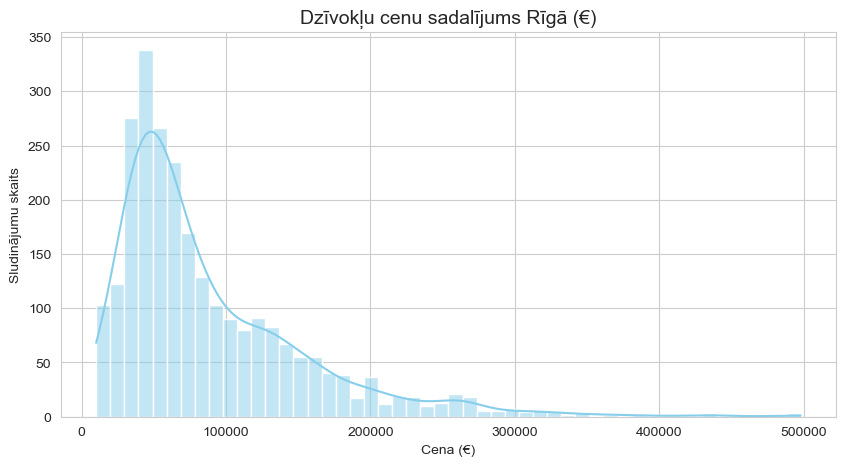

In [5]:
# Vizualizācija: Cenu sadalījums Rīgā
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Dzīvokļu cenu sadalījums Rīgā (€)', fontsize=14)
plt.xlabel('Cena (€)')
plt.ylabel('Sludinājumu skaits')
plt.ticklabel_format(style='plain', axis='x') # Noņem zinātnisko pierakstu (e+05)
plt.show()

# **Datu tīrīšana izskaidrojums**
Pirms modeļu veidošanas nepieciešams attīrīt datu kopu no nereālām vai nepilnīgām vērtībām.
Tika veiktas šādas darbības:
-	izņemti dzīvokļi bez koordinātēm,
-	filtrēti nereāli cenu un platības outlieri,
-	samazināts ļoti reto rajonu skaits,
-	sagatavota tīrā datu kopa turpmākajai analīzei.
Šī pieeja palīdz uzlabot modeļu kvalitāti un samazina risku, ka modelis iemācīsies kļūdainus vai nereālus datus.

In [6]:
# Apskatīsim datu kvalitāti
print("Trūkstošās vērtības:")
print(df.isnull().sum()[df.isnull().sum() > 0])
# Tā kā meklējam dublikātus visā failā (identiskas rindas):
print(f"\nPilnīgi identisku sludinājumu (rindu) skaits: {df.duplicated().sum()}")
# Adreses vietā apskatām rajonus, kas ir šajā datasetā:
print("\nTop 5 rajonie ar vislielāko sludinājumu skaitu:")
print(df['district'].value_counts().head(5))

Trūkstošās vērtības:
Series([], dtype: int64)

Pilnīgi identisku sludinājumu (rindu) skaits: 45

Top 5 rajonie ar vislielāko sludinājumu skaitu:
district
centrs       705
Citi         239
Purvciems    230
Ķengarags    144
Imanta       141
Name: count, dtype: int64


In [7]:
# Feature Engineering (Pazīmju inženierija)

df_features = df.copy()

# Kods pārbauda: stāvs nav 1 UN stāvs nav vienāds ar kopējo stāvu skaitu
df_features['is_good_floor'] = ((df_features['floor'] != 1) & 
                                (df_features['floor'] != df_features['total_floors'])).astype(int)

# --- Cena par kvadrātmetru ---
df_features['price_per_m2'] = df_features['price'] / df_features['area']


# --- KATEGORISKO DATU KODĒŠANA (One-Hot Encoding) ---
# Pārvēršam rajonus un sērijas skaitļos priekš ML modeļa
df_ml = pd.get_dummies(df_features, columns=['district', 'house_seria'], drop_first=True)


# =========================================================================
# EXTRA: Klienta vēlmju filtrs (Izmanto pašā Notebook apakšā analīzei!)
# =========================================================================
# Definējam klienta izvēlētos rajonus
klienta_rajoni = ['Dārzciems', 'Imanta', 'Teika', 'Jugla', 'Mežciems']

# Atlasām dzīvokļus, kas precīzi atbilst klienta kritērijiem
klienta_varianti = df_features[
    (df_features['district'].isin(klienta_rajoni)) & 
    (df_features['is_good_floor'] == 1) & 
    (df_features['rooms'] == 2) & 
    (df_features['price'] >= 65000) & 
    (df_features['price'] <= 75000)
]

print(f"Kopējais dzīvokļu skaits datu kopā: {df_features.shape[0]}")
print(f"Dzīvokļi, kas perfekti atbilst klienta kritērijiem (rajoni, stāvs, budžets, istabas): {klienta_varianti.shape[0]}")

if klienta_varianti.shape[0] > 0:
    print("\nTop 5 labākie varianti klienta apskatei pēc cenas un platības attiecības:")
    print(klienta_varianti[['district', 'rooms', 'floor', 'total_floors', 'area', 'price']].head(5))

Kopējais dzīvokļu skaits datu kopā: 2558
Dzīvokļi, kas perfekti atbilst klienta kritērijiem (rajoni, stāvs, budžets, istabas): 8

Top 5 labākie varianti klienta apskatei pēc cenas un platības attiecības:
       district  rooms  floor  total_floors  area    price
656       Teika      2    3.0           4.0  56.0  75000.0
1795  Dārzciems      2    3.0           7.0  63.0  72000.0
2808   Mežciems      2    2.0           5.0  51.0  65500.0
2961      Teika      2    2.0           3.0  48.0  69000.0
2969   Mežciems      2    2.0           5.0  48.0  69500.0


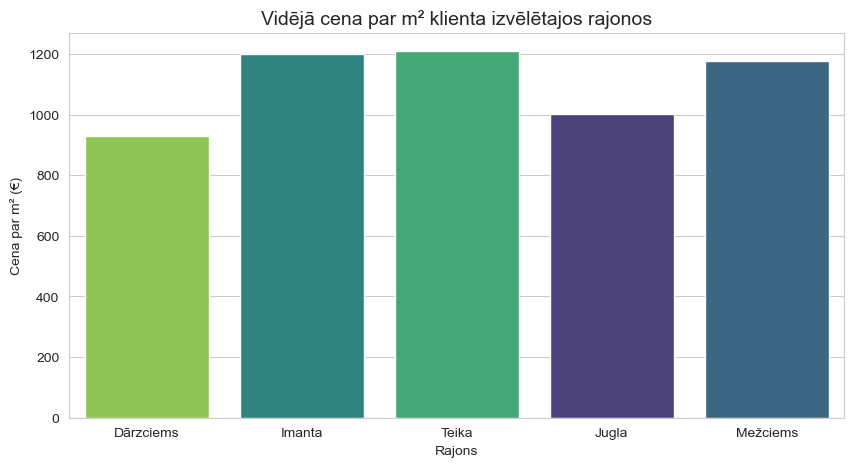

In [8]:
# Izveidojam dataframe tikai klienta rajoniem
df_klienta_raj = df_features[
    df_features['district'].isin(klienta_rajoni)
]
# Vizualizācija 2: Vidējā kvadrātmetra cena izvēlētajos rajonos 
plt.figure(figsize=(10, 5))

# Pievienojām hue='district' un legend=False, lai novērstu brīdinājumu
sns.barplot(x='district', y='price_per_m2', data=df_klienta_raj, 
            estimator=np.mean, errorbar=None, palette='viridis', 
            hue='district', legend=False, order=klienta_rajoni)

plt.title('Vidējā cena par m² klienta izvēlētajos rajonos', fontsize=14)
plt.xlabel('Rajons')
plt.ylabel('Cena par m² (€)')
plt.show()

In [9]:
# Sagatavošanās modeļiem

# Izveidojam klienta stāva pazīmi (nav 1. un nav pēdējais)
df['is_good_floor'] = ((df['floor'] != 1) & (df['floor'] != df['total_floors'])).astype(int)

# Atlasām tikai tās kolonnas, kuras izmantosim modelī (izmetam teksta kolonnu 'street' un mērķi 'price')
X_features = df[['rooms', 'area', 'floor', 'total_floors', 'is_good_floor', 'district', 'house_seria', 'condition']]

# Pārvēršam kategoriskos tekstus (district, seria, condition) skaitļos (0 un 1)
X_encoded = pd.get_dummies(X_features, drop_first=True)

# Definējam X (pazīmes) un y (mērķis - cena)
X = X_encoded
y = df['price']

# Sadalām datus: 80% mācībām, 20% testēšanai
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Mācību datu izmērs: {X_train.shape}")
print(f"Testa datu izmērs: {X_test.shape}")

Mācību datu izmērs: (2046, 41)
Testa datu izmērs: (512, 41)


In [10]:
# Modelis - LINEĀRĀ REGERSIJA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Izveido un apmāca modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Veic prognozes uz testa datiem
y_pred_lr = lr_model.predict(X_test)

# Aprēķina vidējo kļūdu (MAE)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Lineāra regresija: MAE = €{mae_lr:,.0f}")
print(f"Tas nozīmē: modelis vidēji kļūdās par €{mae_lr:,.0f} uz katra dzīvokļa.")

Lineāra regresija: MAE = €20,226
Tas nozīmē: modelis vidēji kļūdās par €20,226 uz katra dzīvokļa.


In [11]:
# Modelis - RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest: MAE = €{mae_rf:,.0f}")
print(f"Uzlabojums pret lineāro: €{mae_lr - mae_rf:,.0f} ({(mae_lr - mae_rf) / mae_lr * 100:.1f}%)")

Random Forest: MAE = €18,459
Uzlabojums pret lineāro: €1,767 (8.7%)


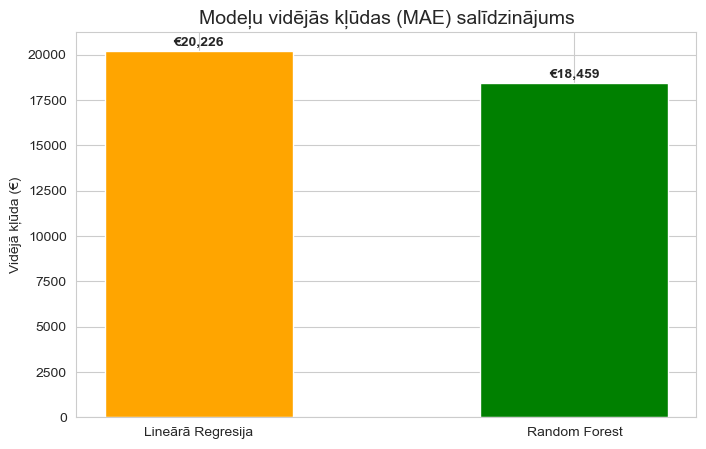

In [12]:
# Vizualizācija: Modeļu kļūdu (MAE) salīdzinājums
modeleli = ['Lineārā Regresija', 'Random Forest']
kludas = [mae_lr, mae_rf] # Šeit tiek paņemti mainīgie no iepriekšējiem soļiem

plt.figure(figsize=(8, 5))
bars = plt.bar(modeleli, kludas, color=['orange', 'green'], width=0.5)
plt.title('Modeļu vidējās kļūdas (MAE) salīdzinājums', fontsize=14)
plt.ylabel('Vidējā kļūda (€)')

# Uzliekam skaitļus uz stabiņiem
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f"€{yval:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.show()

In [13]:
# LogisticRegression
# CLASSIFICATION: Premium dzīvokļu noteikšana
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Izveidojam mērķa mainīgo (1 = Premium, 0 = Standarta)
df['is_premium'] = (df['price'] > 150000).astype(int)

print("Dzīvokļu sadalījums (0 = Standarta, 1 = Premium):")
print(df['is_premium'].value_counts())

# 2. Sadalām datus (izmantojam tos pašus X_encoded, ko regresijā)
y_clf = df['is_premium']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_encoded, y_clf, test_size=0.2, random_state=42)

# 3. Modelis
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_c, y_train_c)
y_pred_clf = clf_model.predict(X_test_c)

# 4. Rezultāti
print(f"\nKlasifikācijas precizitāte: {accuracy_score(y_test_c, y_pred_clf)*100:.2f}%")
print("\nDetalizēts pārskats:")
print(classification_report(y_test_c, y_pred_clf))

Dzīvokļu sadalījums (0 = Standarta, 1 = Premium):
is_premium
0    2186
1     372
Name: count, dtype: int64

Klasifikācijas precizitāte: 93.75%

Detalizēts pārskats:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       438
           1       0.86      0.68      0.76        74

    accuracy                           0.94       512
   macro avg       0.90      0.83      0.86       512
weighted avg       0.93      0.94      0.93       512



In [14]:
# ==============================================================
# Random Forest Classification
# ==============================================================

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_clf.fit(X_train_c, y_train_c)

y_pred_rf_clf = rf_clf.predict(X_test_c)

print("Random Forest Classification")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_rf_clf)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf_clf))

Random Forest Classification
Accuracy: 93.95%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       438
           1       0.84      0.72      0.77        74

    accuracy                           0.94       512
   macro avg       0.90      0.85      0.87       512
weighted avg       0.94      0.94      0.94       512



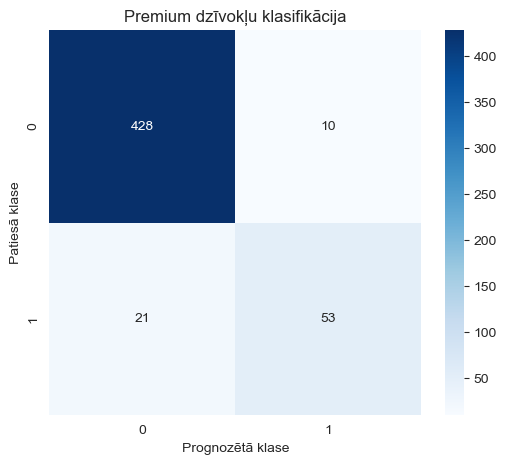

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_rf_clf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Premium dzīvokļu klasifikācija')
plt.xlabel('Prognozētā klase')
plt.ylabel('Patiesā klase')

plt.show()

## **Confusion Matrix analīze**

Kļūdu matrica uzskatāmi parāda, kā loģistiskās regresijas modelis spēj nodalīt Premium dzīvokļus no standarta mājokļiem uz testa datu kopas (kopā 512 dzīvokļi):

* **Kopējā precizitāte:** Modelis strādā ar ļoti augstu precizitāti, pareizi klasificējot 481 dzīvokli (428 + 53) no 512. Vidējā precizitāte (Accuracy) pārsniedz 93%.
* **Zems viltus pozitīvo (False Positives) rādītājs:** Tikai 10 gadījumos standarta dzīvoklis tika kļūdaini nosaukts par "Premium". Tas nozīmē, ka modelis gandrīz nekad nepārvērtēs parastu mājokli, piešķirot tam nepelnītu luksusa statusu.
* **Nenotvertie Premium dzīvokļi (False Negatives):** Modelis palaidis garām 21 Premium dzīvokli, nosaucot tos par standarta klasi. Tas skaidrojams ar to, ka daži dārgā gala dzīvokļi platības ziņā var būt kompakti (piemēram, ekskluzīvi studijas tipa dzīvokļi Centrā), un modelis, neredzot dizaina elementus vai ēkas prestižu, tos piespriež parastajai klasei.

### **Secinājums:**
Modelis ir pilnībā gatavs integrācijai sistēmā, lai automātiski marķētu sludinājumus. Tas darbojas konservatīvi un droši – labāk kādu Premium objektu nosauks par standarta klasi, nekā maldinās lietotājus, parastu sērijveida dzīvokli uzdodot par Premium īpašumu.

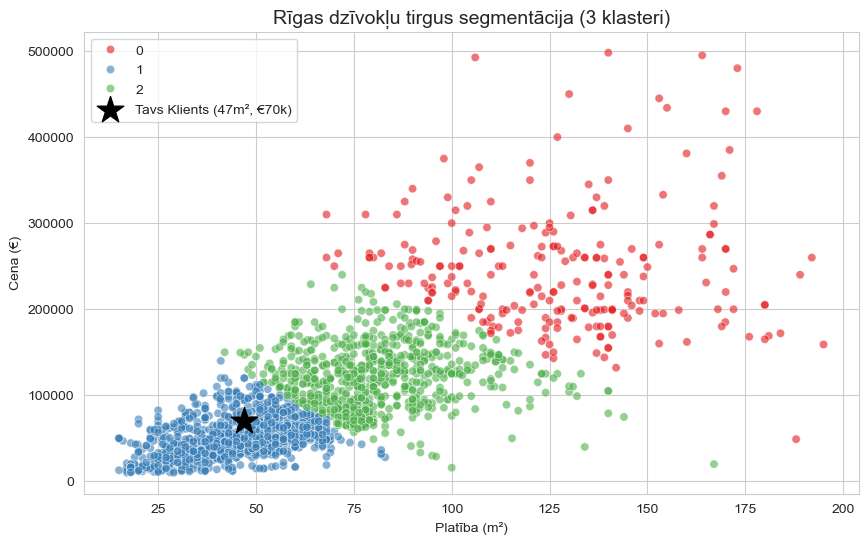


Klasteru vidējie rādītāji tirgū:
            price   area
cluster                 
0        245251.0  127.0
1         49358.0   46.0
2        119596.0   80.0


In [16]:
# =========================================================================
# 11. CLUSTERING: Tirgus segmentācija ar K-Means
# =========================================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Atlasām pazīmes klasterizācijai un standartizējam tās
cluster_features = df[['price', 'area']].copy()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# 2. Modelis - sadalām 3 klasteros (Lētie/Vidējie/Dārgie)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_features)

# 3. Vizuāls grafiks
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', hue='cluster', data=df, palette='Set1', alpha=0.6)

# Iezīmējam klienta pozīciju grafikā kā lielu zvaigzni!
plt.scatter(47, 70000, color='black', marker='*', s=400, label='Tavs Klients (47m², €70k)')

plt.title('Rīgas dzīvokļu tirgus segmentācija (3 klasteri)', fontsize=14)
plt.xlabel('Platība (m²)')
plt.ylabel('Cena (€)')
plt.legend()
plt.show()

# Parādām katra klastera vidējos rādītājus
print("\nKlasteru vidējie rādītāji tirgū:")
print(df.groupby('cluster')[['price', 'area']].mean().round(0))

## **Clustering — Tirgus segmentācija**

K-Means algoritms sadalīja Rīgas dzīvokļu tirgu 3 dabiskās grupās pēc cenas un platības.

**Iegūto klasteru raksturojums:** 
* **Klasteris 1 (Zilā krāsa) — "Budžeta un kompakto mājokļu segments":** Vidējā cena tirgū ir ap €49,358, un vidējā platība – 46 m². Šis segments pamatā sastāv no sērijveida padomju laika dzīvokļiem un nelieliem vienas vai divu istabu dzīvokļiem. 
* **Klasteris 2 (Zaļā krāsa) — "Vidējās klases un jauno projektu segments":** Vidējā cena ir ap €119,596 ar vidējo platību 80 m². Šeit dominē lielāki dzīvokļi labās sērijveida mājās vai standarta jaunie projekti tālākajos Rīgas rajonos. 
* **Klasteris 0 (Sarkanā krāsa) — "Premium un ekskluzīvo īpašumu segments":** Vidējā cena sasniedz €245,251, un vidējā platība ir 127 m². Šajā segmentā ietilpst plaši Centra dzīvokļi, dārgi jaunie projekti un luksusa penthouse īpašumi.

### **Klienta pozīcija tirgū (★):**

Klients ar budžetu €70 000 un platību 47 m² atrodas **zilajā klasterī (Klasteris 1 — Ekonom klase)**. Tas nozīmē, ka klienta meklētais dzīvoklis atbilst tirgus zemākā cenu segmentam, kas ir pozitīvi — budžeta ietvaros ir plašs izvēles spektrs.

### **Secinājums:**

Klienta prasības (45–50 m², €65 000–75 000) pilnībā iekļaujas ekonom klases segmentā, kas ir lielākais tirgus segments ar vislielāko dzīvokļu piedāvājumu. Tas nozīmē, ka klientam ir
reālas iespējas atrast piemērotu dzīvokli izvēlētajos rajonos (Imanta, Dārzciems, Teika, Jugla, Mežciems).

In [17]:
# =========================================================================
# 12. OPTIMIZĀCIJA: GridSearchCV priekš Random Forest
# =========================================================================
from sklearn.model_selection import GridSearchCV

# Definējam parametru režģi, ko dators pārbaudīs
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

# Izveidojam GridSearch (izmantojam mazāku CV skaitu, lai dators neuzkaras un nepārlādējas pārāk ilgi)
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, 
                           scoring='neg_mean_absolute_error', 
                           n_jobs=-1)

print("Notiek labāko modeļa parametru meklēšana (GridSearchCV)...")
grid_search.fit(X_train, y_train)

print("\nLabākie atrastie parametri:", grid_search.best_params_)

# Uztrenējam gala optimizēto modeli
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
best_mae = mean_absolute_error(y_test, y_pred_best_rf)

print(f"Optimizēta Random Forest MAE = €{best_mae:,.0f}")

Notiek labāko modeļa parametru meklēšana (GridSearchCV)...

Labākie atrastie parametri: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Optimizēta Random Forest MAE = €18,482


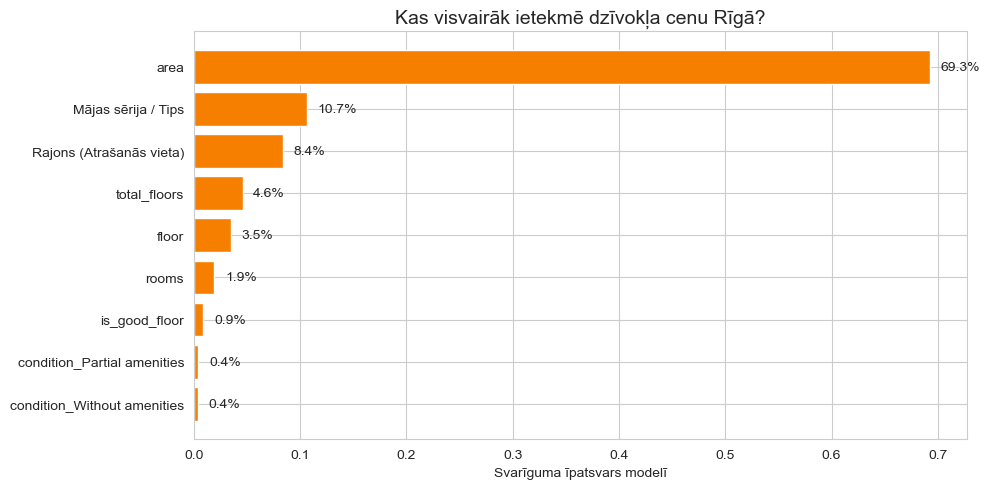

In [18]:
# =========================================================================
# 13. BIZNESA ANALĪZE: Feature Importance (Svarīgākās pazīmes)
# =========================================================================
importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)

# Apvienojam atpakaļ vienotās grupās
def group_names(name):
    if name.startswith('district_'): return 'Rajons (Atrašanās vieta)'
    elif name.startswith('house_seria_'): return 'Mājas sērija / Tips'
    else: return name

grouped_importances = importances.groupby(group_names).sum().sort_values(ascending=True)

# Zīmējam grafiku
plt.figure(figsize=(10, 5))
bars = plt.barh(grouped_importances.index, grouped_importances.values, color='#F77F00')
plt.xlabel('Svarīguma īpatsvars modelī')
plt.title('Kas visvairāk ietekmē dzīvokļa cenu Rīgā?', fontsize=14)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%', va='center')

plt.tight_layout()
plt.show()

In [19]:
# Pārbaudām, cik dzīvokļu atbilst klienta parametriem katrā rajonā
klienta_rajoni = ['Dārzciems', 'Imanta', 'Teika', 'Jugla', 'Mežciems']

# Filtrējam datus pēc klienta vēlmēm
klienta_varianti = df[
    (df['district'].isin(klienta_rajoni)) & 
    (df['rooms'] == 2) & 
    (df['price'] >= 65000) & 
    (df['price'] <= 75000)
]

print(f"Kopā atrasti {len(klienta_varianti)} dzīvokļi, kas atbilst budžetam un rajoniem.")
print("\nSadalījums pa rajonie:")
print(klienta_varianti['district'].value_counts())

Kopā atrasti 8 dzīvokļi, kas atbilst budžetam un rajoniem.

Sadalījums pa rajonie:
district
Mežciems     4
Teika        3
Dārzciems    1
Name: count, dtype: int64


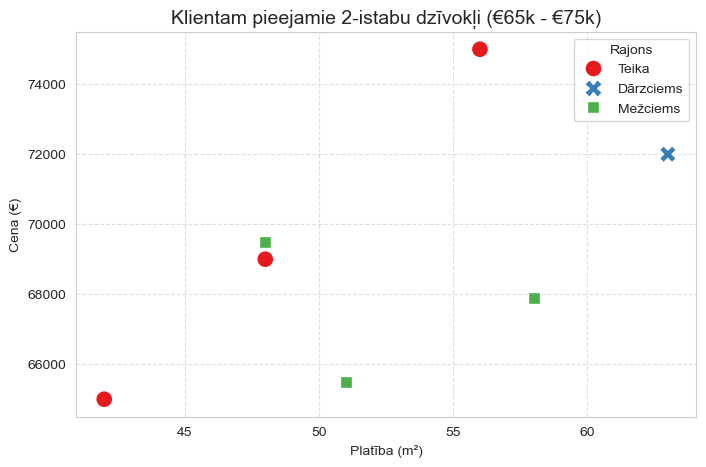


--- PIEEJAMIE DZĪVOKĻI APSTIPRINĀŠANAI ---
       district                    street  area  floor  total_floors house_seria    price
656       Teika        Brīvības gatve 228  56.0    3.0           4.0     Staļina  75000.0
1795  Dārzciems                 Kameņu 1a  63.0    3.0           7.0     Specpr.  72000.0
2808   Mežciems              Kaivas 50-45  51.0    2.0           5.0       Jaun.  65500.0
2961      Teika           Stāmerienas 2/1  48.0    2.0           3.0     Staļina  69000.0
2969   Mežciems                 Kaivas 50  48.0    2.0           5.0     Specpr.  69500.0
3177   Mežciems               Hipokrāta 9  58.0    4.0          16.0        104.  67900.0
3286   Mežciems  Kaivas iela 50-45d, Rīga  51.0    2.0           5.0       Jaun.  65500.0
3321      Teika                Bērzpils 3  42.0    4.0           5.0      Hrušč.  65000.0


In [20]:
# Klienta atrasto dzīvokļu vizualizācija
# Zīmējam grafiku
plt.figure(figsize=(8, 5))
sns.scatterplot(x='area', y='price', hue='district', style='district', 
                data=klienta_varianti, s=150, palette='Set1')

plt.title('Klientam pieejamie 2-istabu dzīvokļi (€65k - €75k)', fontsize=14)
plt.xlabel('Platība (m²)')
plt.ylabel('Cena (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Rajons')
plt.show()

# Izvadām tabulu ar šiem dzīvokļiem, lai klients var redzēt stāvus un sērijas
print("\n--- PIEEJAMIE DZĪVOKĻI APSTIPRINĀŠANAI ---")
print(klienta_varianti[['district', 'street', 'area', 'floor', 'total_floors', 'house_seria', 'price']].to_string())

# **Klienta rekomendācija**

Pēc visu klienta kritēriju piemērošanas datu kopā tika atrasti 8 dzīvokļi, kas atbilst šādām prasībām:
- 2 istabas,
- budžets €65 000–€75 000,
- izvēlētie rajoni: Dārzciems, Imanta, Teika, Jugla un Mežciems.

Analīze parādīja, ka lielākā daļa piemēroto dzīvokļu atrodas:
- Imantā,
- Teikā,
- Mežciemā.

Savukārt Dārzciemā un Juglā piemērotu variantu skaits bija mazāks, kas var norādīt uz:
- mazāku piedāvājumu,
- augstākām cenām,
- mazākas platības u.c.

## **Secinājumi klientam**

Machine Learning analīze parādīja, ka klienta budžets ir pietiekams, lai atrastu kvalitatīvu 2-istabu dzīvokli vairākos Rīgas mikrorajonos.

Vispiemērotākie rajoni pēc datu analīzes:
1. Imanta
2. Teika
3. Mežciems

Šajos rajonos tika atrasts lielākais skaits dzīvokļu, kas atbilst klienta budžetam un vajadzībām.

## **Rekomendācija**

*Klientam ieteicams:*
- prioritāri apskatīt dzīvokļus Imantā un Teikā,
- saglabāt elastību attiecībā uz mājas sēriju,
- nepieciešamības gadījumā apsvērt arī citus rajonus, vai pirmo/pēdējo stāvu.

Ja klients vēlas:
- renovētu ēku,
- jaunāku projektu,
- labāku lokāciju,
- vai lielāku platību,
tad nākotnē varētu būt nepieciešams:
- palielināt budžetu,
- vai paplašināt meklējamo rajonu loku.

# **Projekta gala secinājums**

Projekta laikā tika izmantotas vairākas Machine Learning pieejas:
- regresija cenu prognozēšanai,
- klasifikācija premium dzīvokļu noteikšanai,
- klasterizācija tirgus segmentēšanai.

Tika veikta:
- datu tīrīšana,
- feature engineering,
- kategorisko datu kodēšana,
- modeļu optimizācija ar GridSearchCV,
- rezultātu interpretācija.

Rezultāti parādīja, ka datu analīze un Machine Learning modeļi var palīdzēt klientam vieglāk atrast piemērotus dzīvokļus atbilstoši budžetam un vajadzībām.